<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/polinomsal_regresyon_vs_karar_agaci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd

# DOSYA YOLU HATASI DÜZELTİLDİ:
# Başına eğik çizgi ekleyerek veya direkt adını yazarak ana dizinden güvenli şekilde okuyoruz.
try:
    df = pd.read_csv('/content/sample_data/Position_Salaries.csv')
except FileNotFoundError:
    df = pd.read_csv('Position_Salaries.csv') # Eğer lokal dizindeyse bu yedek yol çalışır

print("======= KEŞİFSEL VERİ ANALİZİ (EDA) =======")
print("------------------------------------------")

# 1. Verinin Boyutu
print(f"📊 Veri Seti Boyutu: {df.shape[0]} Satır, {df.shape[1]} Sütun\n")

# 2. Eksik Veri Kontrolü (Null Check)
print("🔍 Eksik (Null) Değer Kontrolü:")
print(df.isnull().sum(), "\n")

# 3. Veri Tipleri Kontrolü
print("📋 Veri Tipleri ve Yapısı:")
print(df.dtypes, "\n")

# 4. İstatistiki Özet (Maaşların dağılımı, min, max, ortalama değerleri)
print("📈 Verinin İstatistiki Özeti:")
print(df.describe().T)

======= KEŞİFSEL VERİ ANALİZİ (EDA) =======
------------------------------------------
📊 Veri Seti Boyutu: 10 Satır, 3 Sütun

🔍 Eksik (Null) Değer Kontrolü:
Position    0
Level       0
Salary      0
dtype: int64 

📋 Veri Tipleri ve Yapısı:
Position    object
Level        int64
Salary       int64
dtype: object 

📈 Verinin İstatistiki Özeti:
        count      mean            std      min       25%       50%  \
Level    10.0       5.5       3.027650      1.0      3.25       5.5   
Salary   10.0  249500.0  299373.883668  45000.0  65000.00  130000.0   

              75%        max  
Level        7.75       10.0  
Salary  275000.00  1000000.0  


/tmp/ipykernel_538/1836253293.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


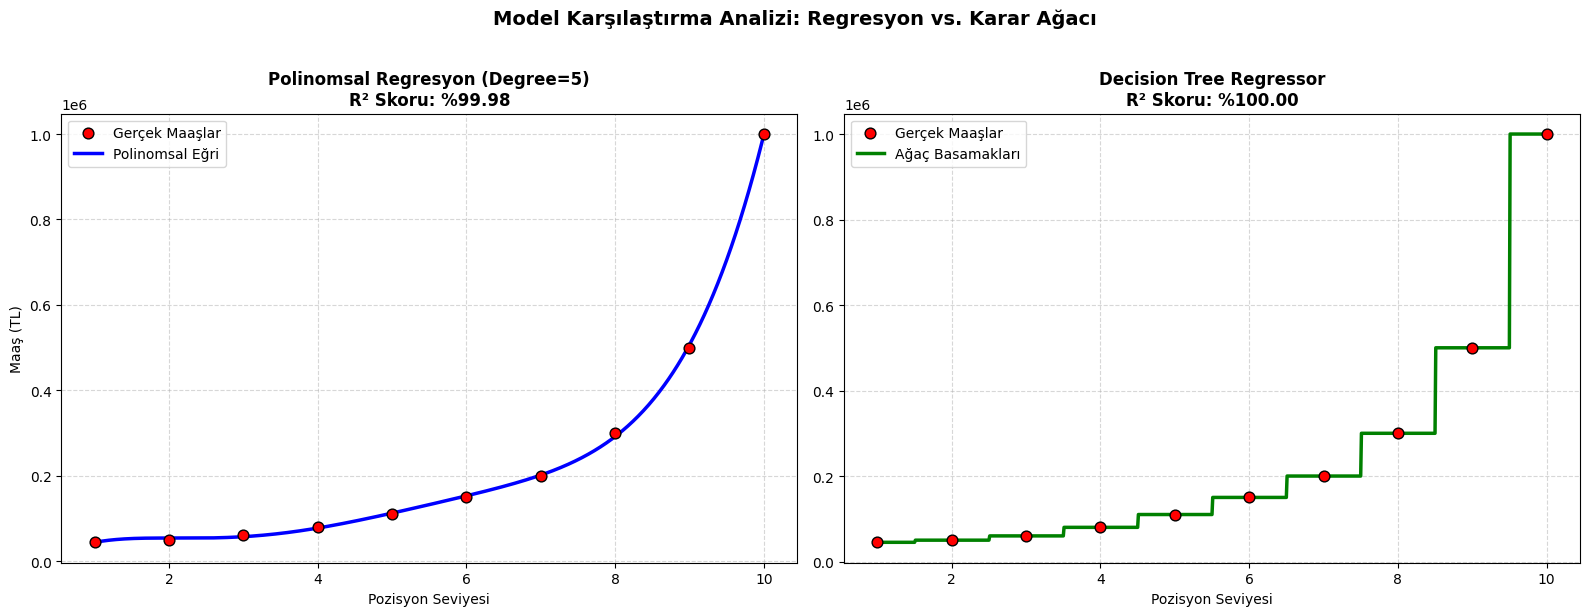

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# 1. Veriyi Okuma
df = pd.read_csv('/content/sample_data/Position_Salaries.csv')
X = df.iloc[:, 1:2].values
y = df.iloc[:, 2].values

# Çizgilerin pürüzsüz/net görünmesi için X eksenini sıklaştırıyoruz
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)

# ==========================================
# MODEL A: Polinomsal Regresyon (Degree=5)
# ==========================================
poly_features = PolynomialFeatures(degree=5)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred_poly = poly_model.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)

# ==========================================
# MODEL B: Decision Tree Regressor (Karar Ağacı)
# ==========================================
# NOT: Veri setimiz çok küçük olduğu için random_state sabitliyoruz
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X, y)

y_pred_tree = tree_model.predict(X)
r2_tree = r2_score(y, y_pred_tree)

# ==========================================
# YAN YANA GÖRSELLEŞTİRME PANELİ
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Sol Grafik: Polinomsal Regresyon
ax1.scatter(X, y, color='red', s=60, edgecolor='black', zorder=3, label='Gerçek Maaşlar')
ax1.plot(X_grid, poly_model.predict(poly_features.fit_transform(X_grid)), color='blue', linewidth=2.5, label='Polinomsal Eğri')
ax1.set_title(f'Polinomsal Regresyon (Degree=5)\nR² Skoru: %{r2_poly*100:.2f}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Pozisyon Seviyesi')
ax1.set_ylabel('Maaş (TL)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Sağ Grafik: Karar Ağacı (Decision Tree)
ax2.scatter(X, y, color='red', s=60, edgecolor='black', zorder=3, label='Gerçek Maaşlar')
ax2.plot(X_grid, tree_model.predict(X_grid), color='green', linewidth=2.5, label='Ağaç Basamakları')
ax2.set_title(f'Decision Tree Regressor\nR² Skoru: %{r2_tree*100:.2f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Pozisyon Seviyesi')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Model Karşılaştırma Analizi: Regresyon vs. Karar Ağacı', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Test etmek istediğimiz yeni pozisyon seviyeleri
yeni_adaylar = np.array([[4.5], [8.5]])

print("======= GERÇEK ZAMANLI MAAŞ TAHMİN ROBOTU =======")
print("=================================================\n")

for aday in yeni_adaylar:
    # FORMAT HATASINI DÜZELTME:
    # Aday verisini (1, -1) ile 2 boyutlu (1 satır, 1 sütun) tablo formatına zorluyoruz.
    aday_2d = aday.reshape(1, -1)

    # 1. Polinomsal Regresyon (Degree=5) tahmini
    aday_poly = poly_features.transform(aday_2d)
    tahmin_poly = poly_model.predict(aday_poly)[0]

    # 2. Decision Tree (Karar Ağacı) tahmini
    tahmin_tree = tree_model.predict(aday_2d)[0]

    print(f"📍 POZİSYON SEVİYESİ: {aday[0]}")
    print(f"   -> Polinomsal Regresyon Önerisi : {tahmin_poly:,.2f} TL")
    print(f"   -> Karar Ağacı (Tree) Önerisi  : {tahmin_tree:,.2f} TL")
    print("-" * 50)

======= GERÇEK ZAMANLI MAAŞ TAHMİN ROBOTU =======

📍 POZİSYON SEVİYESİ: 4.5
   -> Polinomsal Regresyon Önerisi : 93,566.52 TL
   -> Karar Ağacı (Tree) Önerisi  : 80,000.00 TL
--------------------------------------------------
📍 POZİSYON SEVİYESİ: 8.5
   -> Polinomsal Regresyon Önerisi : 375,829.49 TL
   -> Karar Ağacı (Tree) Önerisi  : 300,000.00 TL
--------------------------------------------------
